In [1]:
import tensorflow as tf
import numpy as np
import os
import pandas as pd

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing import image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
IMG_SIZE = (224, 224)

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D()
])

base_model.trainable = False

In [4]:
dataset_path = "C:/Users\Sujal Pal\OneDrive\Desktop/New Deep Learning\CNN/archive (1)"
classes = ["Anemic", "Non-anemic"]

X = []
y = []

for label, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)

        try:
            img = image.load_img(img_path, target_size=IMG_SIZE)
            img_array = image.img_to_array(img)
            img_array = img_array / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            features = model.predict(img_array, verbose=0)

            X.append(features.flatten())
            y.append(label)

        except:
            continue

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)

Feature shape: (4260, 1024)


In [5]:
df = pd.DataFrame(X)
df['label'] = y
df.to_csv("features_resnet_densenet.csv", index=False)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
df

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,label
0,0.000206,0.001052,0.004122,0.000816,0.084523,0.122567,0.000533,0.004121,0.389805,0.000335,...,0.329183,0.134577,0.320534,0.253977,0.457322,0.070546,0.505576,0.073859,0.017822,0
1,0.000167,0.001188,0.005068,0.000460,0.058459,0.100245,0.000555,0.004345,0.266187,0.000210,...,0.000000,1.424561,1.076999,0.519615,0.587605,0.062106,0.683249,0.012633,0.206204,0
2,0.000167,0.001188,0.005068,0.000460,0.058459,0.100245,0.000555,0.004345,0.266187,0.000210,...,0.000000,1.424561,1.076999,0.519615,0.587605,0.062106,0.683249,0.012633,0.206204,0
3,0.000142,0.000985,0.004366,0.000481,0.050661,0.069269,0.000524,0.005362,0.275813,0.000236,...,0.000000,0.397264,0.215408,0.251127,0.256485,0.042231,1.893472,0.043139,0.078313,0
4,0.000140,0.001357,0.004054,0.000717,0.069414,0.077742,0.000795,0.004104,0.270091,0.000388,...,0.188655,0.267003,0.653577,0.366995,0.847343,0.000567,0.954059,0.008022,0.003393,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4255,0.000163,0.000390,0.005752,0.001992,0.081185,0.270096,0.000766,0.004382,0.353182,0.000378,...,0.019778,0.004741,0.015656,0.123661,0.860600,0.025083,4.148193,0.022609,0.024083,1
4256,0.000055,0.000922,0.006089,0.001626,0.064729,0.223226,0.000866,0.004358,0.298135,0.000409,...,0.021581,0.016782,0.054808,0.057146,0.452512,0.000698,4.996065,0.094846,0.010563,1
4257,0.000055,0.000922,0.006089,0.001626,0.064729,0.223226,0.000866,0.004358,0.298135,0.000409,...,0.021581,0.016782,0.054808,0.057146,0.452512,0.000698,4.996065,0.094846,0.010563,1
4258,0.000055,0.000922,0.006089,0.001626,0.064729,0.223226,0.000866,0.004358,0.298135,0.000409,...,0.021581,0.016782,0.054808,0.057146,0.452512,0.000698,4.996065,0.094846,0.010563,1


In [8]:
df.shape

(4260, 1025)

In [10]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train shape:", y_train.shape)
print("Test shape:", y_test.shape)

Train shape: (3408, 1024)
Test shape: (852, 1024)
Train shape: (3408,)
Test shape: (852,)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [14]:
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print("Best LR Params:", grid_lr.best_params_)

y_pred_lr = grid_lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))

Best LR Params: {'C': 1, 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       512
           1       0.93      0.88      0.90       340

    accuracy                           0.92       852
   macro avg       0.92      0.92      0.92       852
weighted avg       0.92      0.92      0.92       852



In [15]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)

y_pred_rf = grid_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

Best RF Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       512
           1       0.99      0.85      0.91       340

    accuracy                           0.94       852
   macro avg       0.95      0.92      0.93       852
weighted avg       0.94      0.94      0.93       852



In [16]:
from sklearn.svm import SVC

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid_svm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

print("Best SVM Params:", grid_svm.best_params_)

y_pred_svm = grid_svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm))

Best SVM Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       512
           1       0.99      0.96      0.98       340

    accuracy                           0.98       852
   macro avg       0.99      0.98      0.98       852
weighted avg       0.98      0.98      0.98       852



In [17]:
#Comparison of all Machine learning Models
from sklearn.metrics import accuracy_score

results = {
    "LR": accuracy_score(y_test, y_pred_lr),
    "RF": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
}

for k, v in results.items():
    print(f"{k}: {v:.4f}")

LR: 0.9237
RF: 0.9354
SVM: 0.9836


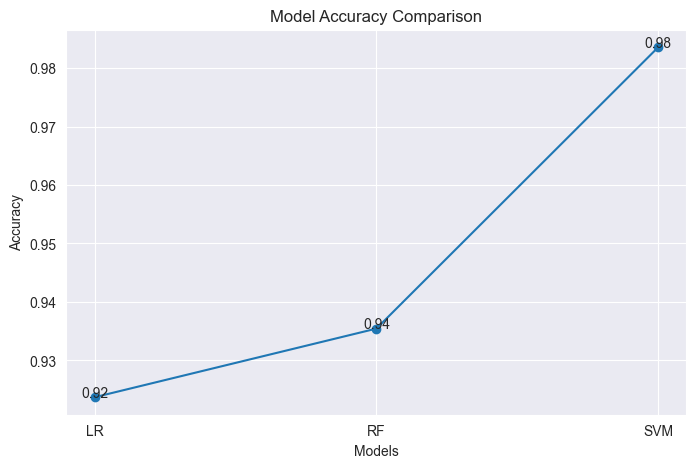

In [19]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(8,5))
plt.plot(models, accuracies, marker='o', linestyle='-')

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.grid(True)

for i, v in enumerate(accuracies):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

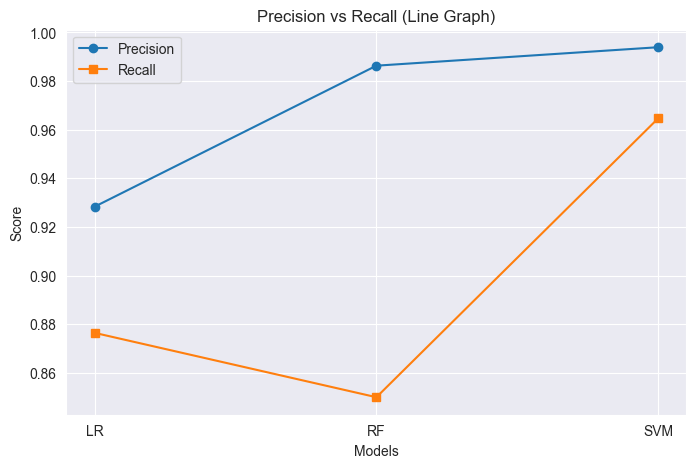

In [20]:
#precision and recall Graph
from sklearn.metrics import precision_score, recall_score

precision = [
    precision_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_svm),
]

recall = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_svm),
]

x = range(len(models))

plt.figure(figsize=(8,5))
plt.plot(x, precision, marker='o', label='Precision')
plt.plot(x, recall, marker='s', label='Recall')

plt.xticks(x, models)
plt.title("Precision vs Recall (Line Graph)")
plt.xlabel("Models")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.show()

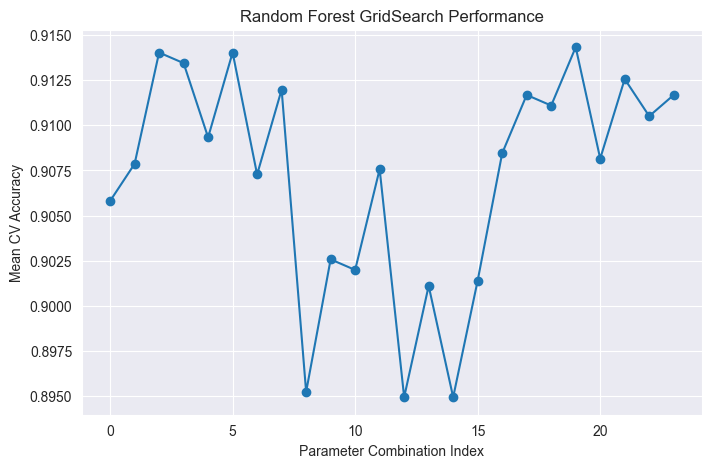

In [21]:
#GridSearch Performance
import pandas as pd

rf_results = pd.DataFrame(grid_rf.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(rf_results['mean_test_score'], marker='o')

plt.title("Random Forest GridSearch Performance")
plt.xlabel("Parameter Combination Index")
plt.ylabel("Mean CV Accuracy")
plt.grid(True)

plt.show()

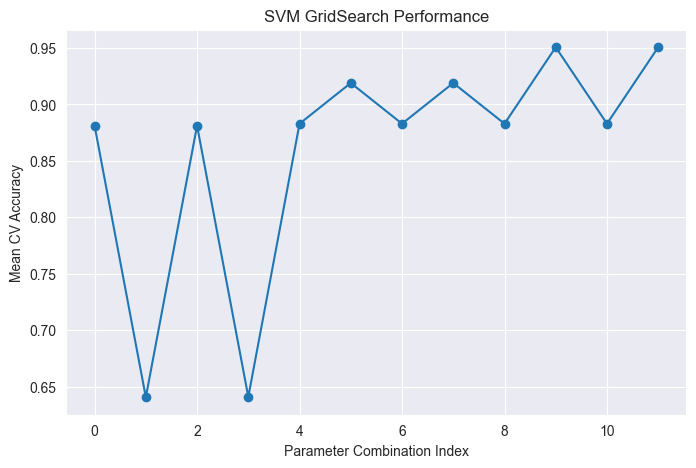

In [22]:
svm_results = pd.DataFrame(grid_svm.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(svm_results['mean_test_score'], marker='o')

plt.title("SVM GridSearch Performance")
plt.xlabel("Parameter Combination Index")
plt.ylabel("Mean CV Accuracy")
plt.grid(True)

plt.show()

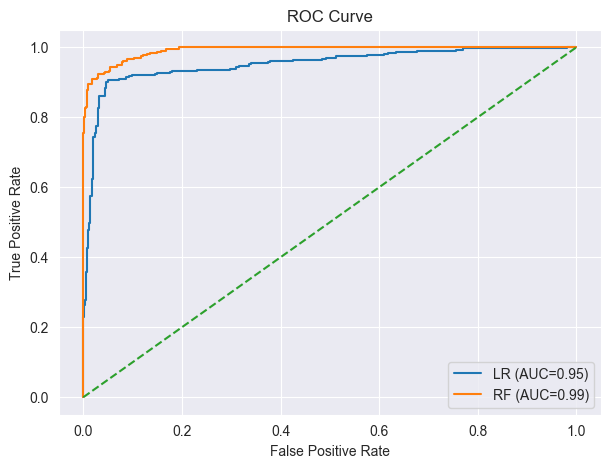

In [23]:
#ROC Curve
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7,5))

def plot_roc(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plot_roc(grid_lr.best_estimator_, X_test_scaled, y_test, "LR")
plot_roc(grid_rf.best_estimator_, X_test, y_test, "RF")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import joblib
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train_scaled, y_train)

joblib.dump(svm, "svm_model_densenet121.pkl")

joblib.dump(scaler, "scaler_densenet121.pkl")

print("Model and scaler saved!")

Model and scaler saved!


In [25]:
import joblib

svm_model = joblib.load("svm_model_densenet121.pkl")
scaler = joblib.load("scaler_densenet121.pkl")

In [26]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing import image
import numpy as np

IMG_SIZE = (224,224)

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

feature_model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D()
])

base_model.trainable = False

In [27]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Extract features
    features = feature_model.predict(img_array, verbose=0)
    features = features.flatten().reshape(1, -1)

    # Scale features
    features_scaled = scaler.transform(features)

    # Predict
    prediction = svm_model.predict(features_scaled)[0]
    prob = svm_model.predict_proba(features_scaled)[0]

    if prediction == 0:
        print(f"Prediction: Anemic")
        print(f"Confidence: {prob[0]*100:.2f}%")
    else:
        print(f"Prediction: Non-Anemic")
        print(f"Confidence: {prob[1]*100:.2f}%")

In [31]:
predict_image(r"C:\Users\Sujal Pal\OneDrive\Desktop\New Deep Learning\CNN\archive (1)\Anemic\Anemic-262 (8).png")

Prediction: Anemic
Confidence: 99.29%
